## Machine Learning on Synthetic Data Adjustment

🚀 CYBERSECURITY ML EXPERIMENTS
📋 Testing synthetic data impact across three research designs:
   1. Data Augmentation Focus
   2. Class Imbalance Focus
   3. Attack Augmentation Focus
🤖 Models: SVM, Random Forest
📊 Metrics: Accuracy, Precision, Recall, F1, ROC-AUC
📂 Loading data from: ../data/mixed/mixed_five_email_phishing_Phishing_and_Spam_Email_Campaigns_100+100.csv
🔧 Preprocessing data...
📊 Final dataset shape: (200, 5)
📈 Label distribution:
   Benign: 97 (48.5%)
   Malicious: 103 (51.5%)
🤖 Synthetic distribution:
   Real-world: 100 (50.0%)
   Synthetic: 100 (50.0%)
✅ Experiment initialized with 200 samples
📊 Features: 3 columns
🎯 Models: ['Random Forest', 'SVM']

🚀 RUNNING ALL CYBERSECURITY ML EXPERIMENTS

🔬 STUDY DESIGN 1: DATA AUGMENTATION FOCUS
🎯 Research Question: How does synthetic data augmentation affect model performance?
📊 Fixed: Malicious ratio in synthetic = 0.5
📈 Varying: Synthetic percentage = [0, 10, 20, 30, 40, 50]

📊 Testing synthetic percentage: 0%
   🔄 Training R

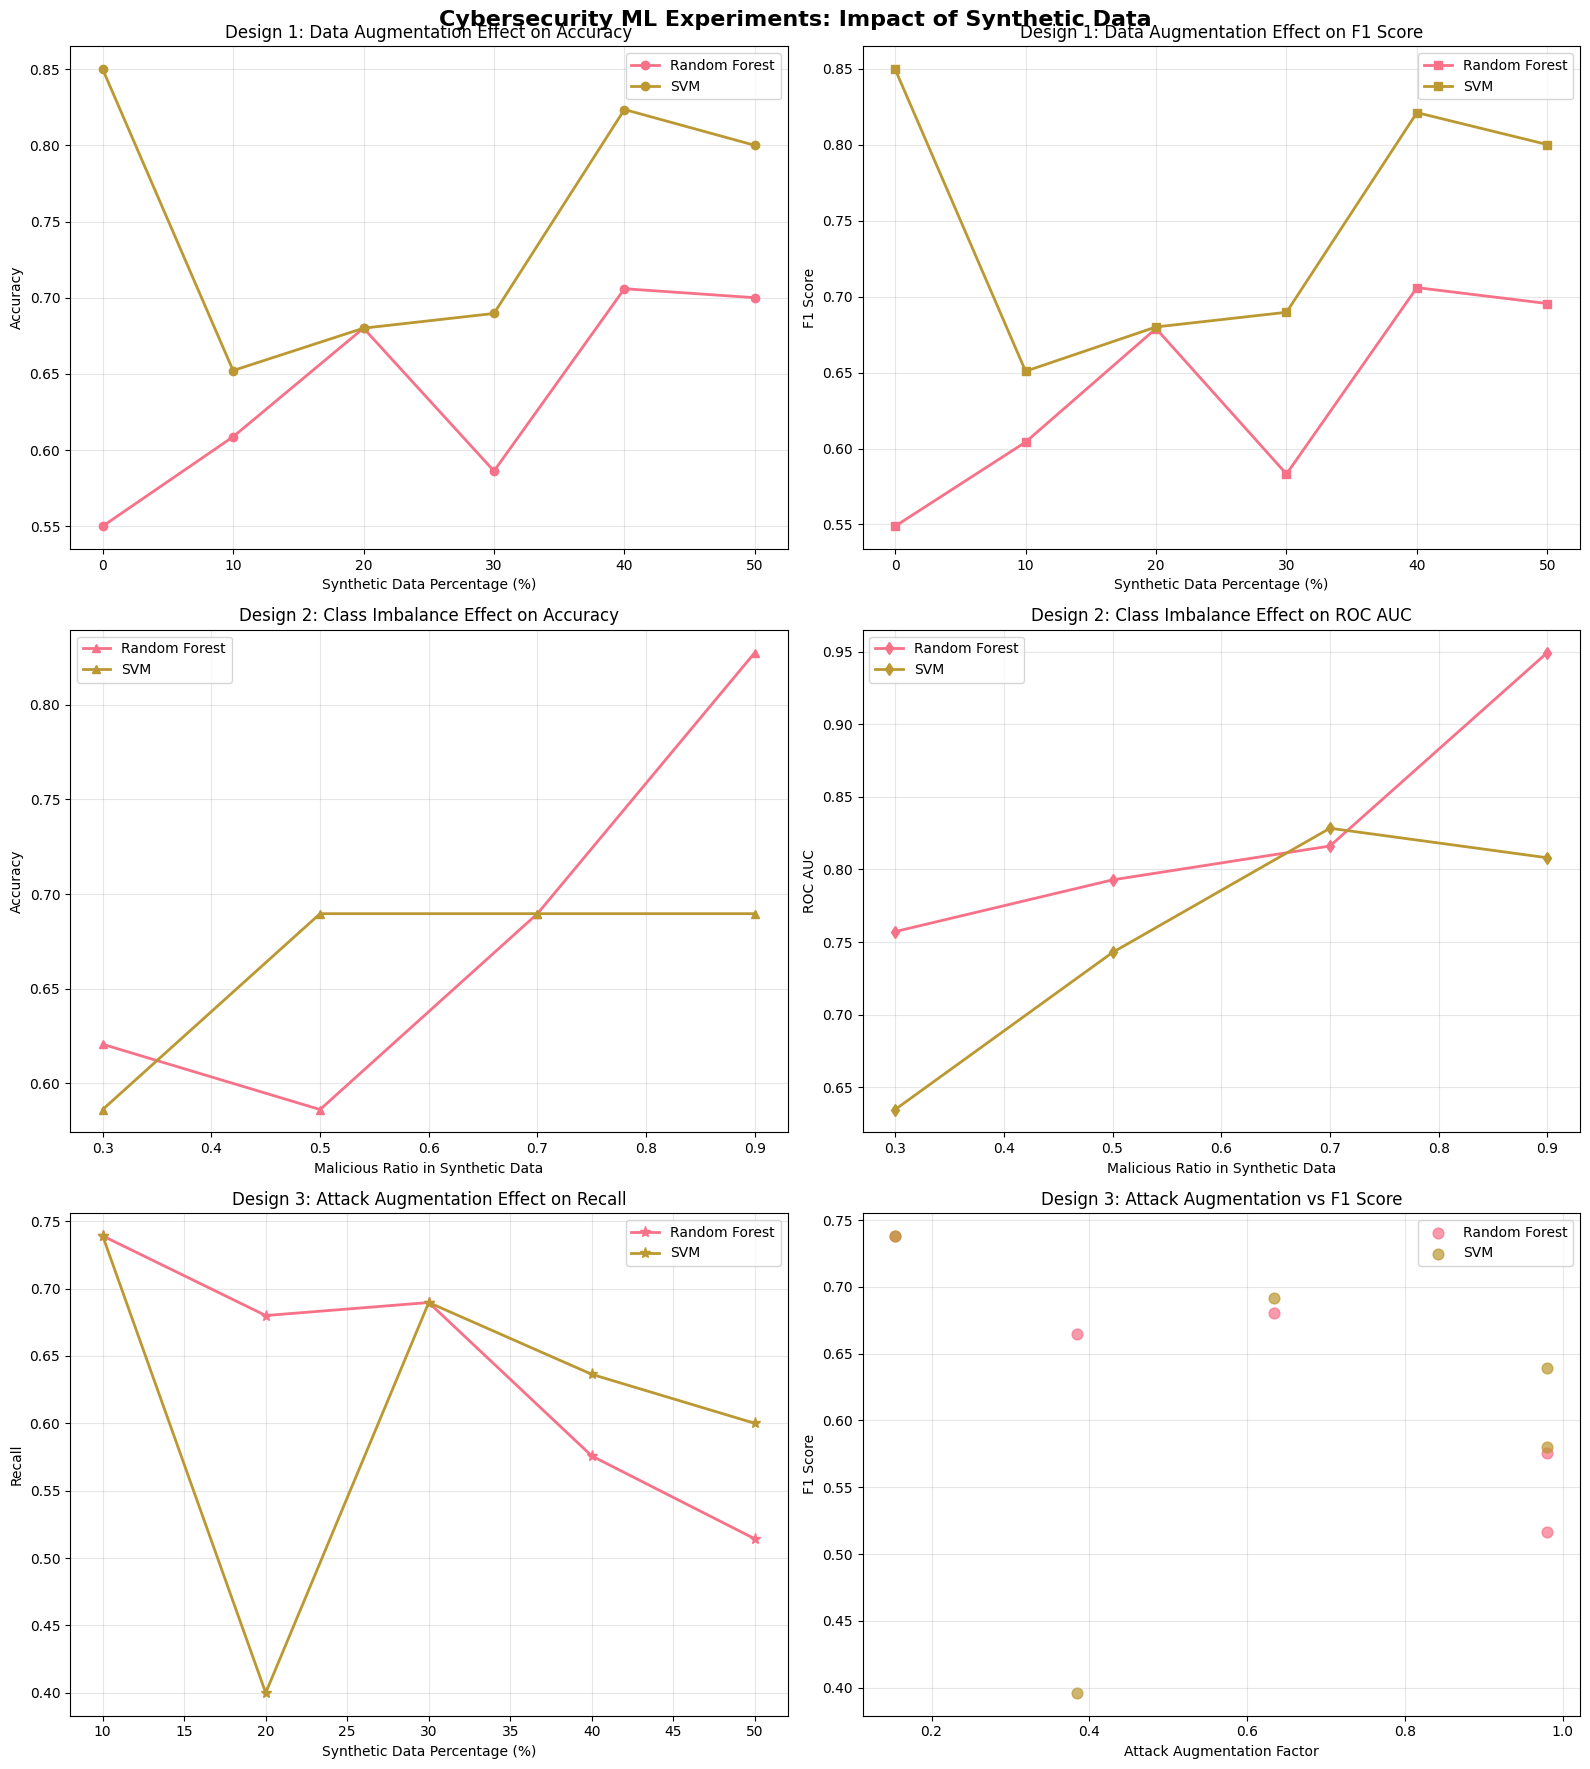


📊 COMPREHENSIVE EXPERIMENT SUMMARY REPORT
🔬 Total Experiments: 30
📋 Study Designs: 3
🤖 ML Models: 2

🏆 BEST PERFORMING CONFIGURATIONS
--------------------------------------------------

📈 Design_1_Augmentation:
   Best Model: SVM
   Synthetic %: 0.0%
   Malicious Ratio: 0.50
   F1 Score: 0.850
   Accuracy: 0.850
   ROC AUC: 0.860

📈 Design_2_Imbalance:
   Best Model: Random Forest
   Synthetic %: 30.0%
   Malicious Ratio: 0.90
   F1 Score: 0.826
   Accuracy: 0.828
   ROC AUC: 0.949

📈 Design_3_Attack_Focus:
   Best Model: Random Forest
   Synthetic %: 10.0%
   Malicious Ratio: 0.80
   F1 Score: 0.738
   Accuracy: 0.739
   ROC AUC: 0.856

🤖 MODEL PERFORMANCE COMPARISON
--------------------------------------------------
              accuracy            f1        roc_auc       
                  mean    std   mean    std    mean    std
model                                                     
Random Forest    0.650  0.082  0.647  0.081   0.772  0.078
SVM              0.681  0.108  0.67

In [3]:
# Cybersecurity ML Experiments: Impact of Synthetic Data on Model Performance
# Implements three study designs with systematic ratio adjustments

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
from sklearn.impute import SimpleImputer
import time
from collections import defaultdict

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

class CybersecurityMLExperiment:
    """
    Comprehensive ML experiment framework for studying synthetic data impact
    on cybersecurity model performance across three research designs.
    """
    
    def __init__(self, data_path, label_column='label', synthetic_column='synthetic', 
                 test_size=0.2, random_state=42):
        """
        Initialize the experiment framework.
        
        Args:
            data_path (str): Path to the mixed dataset
            label_column (str): Name of the label column
            synthetic_column (str): Name of the synthetic indicator column
            test_size (float): Test set proportion (default: 0.2)
            random_state (int): Random state for reproducibility
        """
        self.data_path = data_path
        self.label_column = label_column
        self.synthetic_column = synthetic_column
        self.test_size = test_size
        self.random_state = random_state
        
        # Load and preprocess data
        self.df = self._load_and_preprocess_data()
        self.results = defaultdict(list)
        
        # Initialize models
        self.models = {
            'Random Forest': RandomForestClassifier(
                n_estimators=100,
                random_state=random_state,
                class_weight='balanced'  # Handle class imbalance
            ),
            'SVM': SVC(
                kernel='rbf',
                random_state=random_state,
                probability=True,  # Enable probability prediction for ROC
                class_weight='balanced'
            )
        }
        
        print(f"✅ Experiment initialized with {len(self.df)} samples")
        print(f"📊 Features: {len(self._get_feature_columns())} columns")
        print(f"🎯 Models: {list(self.models.keys())}")
    
    def _load_and_preprocess_data(self):
        """Load and preprocess the mixed dataset."""
        print(f"📂 Loading data from: {self.data_path}")
        
        # Load data
        df = pd.read_csv(self.data_path)
        
        # Basic validation
        required_cols = [self.label_column, self.synthetic_column]
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        # Handle missing values
        print(f"🔧 Preprocessing data...")
        original_shape = df.shape
        
        # Remove rows with missing labels
        df = df.dropna(subset=[self.label_column, self.synthetic_column])
        
        if df.shape[0] != original_shape[0]:
            print(f"⚠️  Removed {original_shape[0] - df.shape[0]} rows with missing labels")
        
        # Encode categorical variables
        feature_cols = self._get_feature_columns(df.columns)
        for col in feature_cols:
            if df[col].dtype == 'object':
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
        
        # Display basic statistics
        print(f"📊 Final dataset shape: {df.shape}")
        print(f"📈 Label distribution:")
        label_dist = df[self.label_column].value_counts().sort_index()
        for label, count in label_dist.items():
            label_name = "Benign" if label == 0 else "Malicious" if label == 1 else f"Class {label}"
            print(f"   {label_name}: {count:,} ({count/len(df)*100:.1f}%)")
        
        print(f"🤖 Synthetic distribution:")
        synth_dist = df[self.synthetic_column].value_counts().sort_index()
        for synth, count in synth_dist.items():
            synth_name = "Real-world" if synth == 0 else "Synthetic"
            print(f"   {synth_name}: {count:,} ({count/len(df)*100:.1f}%)")
        
        return df
    
    def _get_feature_columns(self, columns=None):
        """Get feature column names (excluding label and synthetic columns)."""
        if columns is None:
            columns = self.df.columns
        
        exclude_cols = {self.label_column, self.synthetic_column}
        return [col for col in columns if col not in exclude_cols]
    
    def _create_balanced_subset(self, synthetic_pct, malicious_ratio_in_synthetic=0.5):
        """
        Create a balanced subset with specified synthetic percentage and malicious ratio.
        
        Args:
            synthetic_pct (float): Target percentage of synthetic data (0-50)
            malicious_ratio_in_synthetic (float): Ratio of malicious samples in synthetic data
            
        Returns:
            pd.DataFrame: Balanced subset
        """
        
        # Separate real and synthetic data
        real_data = self.df[self.df[self.synthetic_column] == 0].copy()
        synthetic_data = self.df[self.df[self.synthetic_column] == 1].copy()
        
        if synthetic_pct == 0:
            # Use only real data
            return real_data.sample(frac=1, random_state=self.random_state).reset_index(drop=True)
        
        # Calculate target sample sizes
        total_real = len(real_data)
        target_synthetic = int(total_real * synthetic_pct / (100 - synthetic_pct))
        
        # Get malicious and benign synthetic samples
        synth_malicious = synthetic_data[synthetic_data[self.label_column] == 1]
        synth_benign = synthetic_data[synthetic_data[self.label_column] == 0]
        
        target_synth_malicious = int(target_synthetic * malicious_ratio_in_synthetic)
        target_synth_benign = target_synthetic - target_synth_malicious
        
        # Sample synthetic data
        selected_synth_parts = []
        
        if target_synth_malicious > 0 and len(synth_malicious) > 0:
            n_mal = min(target_synth_malicious, len(synth_malicious))
            selected_synth_parts.append(
                synth_malicious.sample(n=n_mal, random_state=self.random_state)
            )
        
        if target_synth_benign > 0 and len(synth_benign) > 0:
            n_ben = min(target_synth_benign, len(synth_benign))
            selected_synth_parts.append(
                synth_benign.sample(n=n_ben, random_state=self.random_state)
            )
        
        # Combine data
        if selected_synth_parts:
            selected_synthetic = pd.concat(selected_synth_parts, ignore_index=True)
            combined_data = pd.concat([real_data, selected_synthetic], ignore_index=True)
        else:
            combined_data = real_data.copy()
        
        # Shuffle and return
        return combined_data.sample(frac=1, random_state=self.random_state).reset_index(drop=True)
    
    def _train_and_evaluate_models(self, X_train, X_test, y_train, y_test, experiment_info):
        """Train and evaluate all models on given data splits."""
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Handle any remaining missing values
        imputer = SimpleImputer(strategy='mean')
        X_train_scaled = imputer.fit_transform(X_train_scaled)
        X_test_scaled = imputer.transform(X_test_scaled)
        
        experiment_results = []
        
        for model_name, model in self.models.items():
            print(f"   🔄 Training {model_name}...")
            
            # Train model
            start_time = time.time()
            model.fit(X_train_scaled, y_train)
            train_time = time.time() - start_time
            
            # Make predictions
            start_time = time.time()
            y_pred = model.predict(X_test_scaled)
            y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
            predict_time = time.time() - start_time
            
            # Calculate metrics
            metrics = {
                'model': model_name,
                'accuracy': accuracy_score(y_test, y_pred),
                'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
                'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
                'train_time': train_time,
                'predict_time': predict_time,
                'train_samples': len(X_train),
                'test_samples': len(X_test)
            }
            
            # Add ROC AUC if binary classification
            if len(np.unique(y_test)) == 2 and y_proba is not None:
                metrics['roc_auc'] = roc_auc_score(y_test, y_proba)
            else:
                metrics['roc_auc'] = np.nan
            
            # Add experiment information
            metrics.update(experiment_info)
            
            experiment_results.append(metrics)
            
            print(f"     ✅ {model_name}: Accuracy={metrics['accuracy']:.3f}, "
                  f"F1={metrics['f1']:.3f}, ROC-AUC={metrics['roc_auc']:.3f}")
        
        return experiment_results
    
    def run_study_design_1(self, synthetic_percentages=[0, 10, 20, 30, 40, 50], 
                          malicious_ratio_fixed=0.5):
        """
        Study Design 1: Data Augmentation Focus
        Fixed malicious ratio, varying synthetic percentage.
        
        Args:
            synthetic_percentages (list): Synthetic data percentages to test
            malicious_ratio_fixed (float): Fixed malicious ratio in synthetic data
        """
        
        print(f"\n🔬 STUDY DESIGN 1: DATA AUGMENTATION FOCUS")
        print(f"="*60)
        print(f"🎯 Research Question: How does synthetic data augmentation affect model performance?")
        print(f"📊 Fixed: Malicious ratio in synthetic = {malicious_ratio_fixed}")
        print(f"📈 Varying: Synthetic percentage = {synthetic_percentages}")
        
        design_1_results = []
        
        for synth_pct in synthetic_percentages:
            print(f"\n📊 Testing synthetic percentage: {synth_pct}%")
            
            # Create balanced subset
            subset_data = self._create_balanced_subset(synth_pct, malicious_ratio_fixed)
            
            # Extract features and labels
            feature_cols = self._get_feature_columns()
            X = subset_data[feature_cols]
            y = subset_data[self.label_column]
            
            # Train-test split
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=self.test_size, random_state=self.random_state, 
                stratify=y
            )
            
            # Experiment info
            experiment_info = {
                'study_design': 'Design_1_Augmentation',
                'synthetic_pct': synth_pct,
                'malicious_ratio_in_synthetic': malicious_ratio_fixed,
                'total_samples': len(subset_data),
                'real_samples': len(subset_data[subset_data[self.synthetic_column] == 0]),
                'synthetic_samples': len(subset_data[subset_data[self.synthetic_column] == 1])
            }
            
            # Train and evaluate models
            results = self._train_and_evaluate_models(X_train, X_test, y_train, y_test, experiment_info)
            design_1_results.extend(results)
        
        self.results['design_1'] = design_1_results
        print(f"\n✅ Study Design 1 completed: {len(design_1_results)} experiments")
        return design_1_results
    
    def run_study_design_2(self, synthetic_pct_fixed=30, 
                          malicious_ratios=[0.3, 0.5, 0.7, 0.9]):
        """
        Study Design 2: Class Imbalance Focus
        Fixed synthetic percentage, varying malicious ratio.
        
        Args:
            synthetic_pct_fixed (float): Fixed synthetic data percentage
            malicious_ratios (list): Malicious ratios in synthetic data to test
        """
        
        print(f"\n🔬 STUDY DESIGN 2: CLASS IMBALANCE FOCUS")
        print(f"="*60)
        print(f"🎯 Research Question: How does synthetic data help with class imbalance?")
        print(f"📊 Fixed: Synthetic percentage = {synthetic_pct_fixed}%")
        print(f"📈 Varying: Malicious ratio in synthetic = {malicious_ratios}")
        
        design_2_results = []
        
        for mal_ratio in malicious_ratios:
            print(f"\n📊 Testing malicious ratio: {mal_ratio:.1f}")
            
            # Create balanced subset
            subset_data = self._create_balanced_subset(synthetic_pct_fixed, mal_ratio)
            
            # Extract features and labels
            feature_cols = self._get_feature_columns()
            X = subset_data[feature_cols]
            y = subset_data[self.label_column]
            
            # Train-test split
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=self.test_size, random_state=self.random_state, 
                stratify=y
            )
            
            # Experiment info
            experiment_info = {
                'study_design': 'Design_2_Imbalance',
                'synthetic_pct': synthetic_pct_fixed,
                'malicious_ratio_in_synthetic': mal_ratio,
                'total_samples': len(subset_data),
                'real_samples': len(subset_data[subset_data[self.synthetic_column] == 0]),
                'synthetic_samples': len(subset_data[subset_data[self.synthetic_column] == 1])
            }
            
            # Train and evaluate models
            results = self._train_and_evaluate_models(X_train, X_test, y_train, y_test, experiment_info)
            design_2_results.extend(results)
        
        self.results['design_2'] = design_2_results
        print(f"\n✅ Study Design 2 completed: {len(design_2_results)} experiments")
        return design_2_results
    
    def run_study_design_3(self, synthetic_percentages=[10, 20, 30, 40, 50], 
                          malicious_ratio_high=0.8):
        """
        Study Design 3: Attack Augmentation Focus
        High malicious ratio, varying synthetic percentage.
        
        Args:
            synthetic_percentages (list): Synthetic data percentages to test
            malicious_ratio_high (float): High malicious ratio in synthetic data
        """
        
        print(f"\n🔬 STUDY DESIGN 3: ATTACK AUGMENTATION FOCUS")
        print(f"="*60)
        print(f"🎯 Research Question: How does synthetic attack data improve rare event detection?")
        print(f"📊 Fixed: High malicious ratio in synthetic = {malicious_ratio_high}")
        print(f"📈 Varying: Synthetic percentage = {synthetic_percentages}")
        
        design_3_results = []
        
        for synth_pct in synthetic_percentages:
            print(f"\n📊 Testing synthetic percentage: {synth_pct}% (attack-focused)")
            
            # Create balanced subset
            subset_data = self._create_balanced_subset(synth_pct, malicious_ratio_high)
            
            # Extract features and labels
            feature_cols = self._get_feature_columns()
            X = subset_data[feature_cols]
            y = subset_data[self.label_column]
            
            # Train-test split
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=self.test_size, random_state=self.random_state, 
                stratify=y
            )
            
            # Calculate attack augmentation factor
            real_malicious = len(subset_data[
                (subset_data[self.synthetic_column] == 0) & 
                (subset_data[self.label_column] == 1)
            ])
            synth_malicious = len(subset_data[
                (subset_data[self.synthetic_column] == 1) & 
                (subset_data[self.label_column] == 1)
            ])
            attack_augmentation_factor = synth_malicious / real_malicious if real_malicious > 0 else 0
            
            # Experiment info
            experiment_info = {
                'study_design': 'Design_3_Attack_Focus',
                'synthetic_pct': synth_pct,
                'malicious_ratio_in_synthetic': malicious_ratio_high,
                'attack_augmentation_factor': attack_augmentation_factor,
                'total_samples': len(subset_data),
                'real_samples': len(subset_data[subset_data[self.synthetic_column] == 0]),
                'synthetic_samples': len(subset_data[subset_data[self.synthetic_column] == 1])
            }
            
            # Train and evaluate models
            results = self._train_and_evaluate_models(X_train, X_test, y_train, y_test, experiment_info)
            design_3_results.extend(results)
        
        self.results['design_3'] = design_3_results
        print(f"\n✅ Study Design 3 completed: {len(design_3_results)} experiments")
        return design_3_results
    
    def run_all_experiments(self):
        """Run all three study designs."""
        print(f"\n🚀 RUNNING ALL CYBERSECURITY ML EXPERIMENTS")
        print(f"="*60)
        
        # Run all three study designs
        self.run_study_design_1()
        self.run_study_design_2()
        self.run_study_design_3()
        
        # Combine all results
        all_results = []
        for design_results in self.results.values():
            all_results.extend(design_results)
        
        self.all_results_df = pd.DataFrame(all_results)
        
        print(f"\n🎉 ALL EXPERIMENTS COMPLETED!")
        print(f"📊 Total experiments: {len(all_results)}")
        print(f"🎯 Study designs: {len(self.results)}")
        print(f"🤖 Models tested: {len(self.models)}")
        
        return self.all_results_df
    
    def plot_results(self, save_plots=True):
        """Create comprehensive visualizations of experiment results."""
        
        if not hasattr(self, 'all_results_df') or self.all_results_df.empty:
            print("No results to plot. Run experiments first.")
            return
        
        # Set up the plotting area
        fig, axes = plt.subplots(3, 2, figsize=(16, 18))
        fig.suptitle('Cybersecurity ML Experiments: Impact of Synthetic Data', 
                     fontsize=16, fontweight='bold')
        
        # Design 1: Data Augmentation Focus
        self._plot_design_1(axes[0, :])
        
        # Design 2: Class Imbalance Focus  
        self._plot_design_2(axes[1, :])
        
        # Design 3: Attack Augmentation Focus
        self._plot_design_3(axes[2, :])
        
        plt.tight_layout()
        
        if save_plots:
            plt.savefig('cybersecurity_ml_experiments.png', dpi=300, bbox_inches='tight')
            print(f"📁 Plots saved as 'cybersecurity_ml_experiments.png'")
        
        plt.show()
    
    def _plot_design_1(self, axes):
        """Plot results for Study Design 1."""
        design_1_data = self.all_results_df[
            self.all_results_df['study_design'] == 'Design_1_Augmentation'
        ]
        
        # Accuracy by synthetic percentage
        ax1 = axes[0]
        for model in design_1_data['model'].unique():
            model_data = design_1_data[design_1_data['model'] == model]
            ax1.plot(model_data['synthetic_pct'], model_data['accuracy'], 
                    marker='o', label=model, linewidth=2)
        
        ax1.set_xlabel('Synthetic Data Percentage (%)')
        ax1.set_ylabel('Accuracy')
        ax1.set_title('Design 1: Data Augmentation Effect on Accuracy')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # F1 Score by synthetic percentage
        ax2 = axes[1]
        for model in design_1_data['model'].unique():
            model_data = design_1_data[design_1_data['model'] == model]
            ax2.plot(model_data['synthetic_pct'], model_data['f1'], 
                    marker='s', label=model, linewidth=2)
        
        ax2.set_xlabel('Synthetic Data Percentage (%)')
        ax2.set_ylabel('F1 Score')
        ax2.set_title('Design 1: Data Augmentation Effect on F1 Score')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    def _plot_design_2(self, axes):
        """Plot results for Study Design 2."""
        design_2_data = self.all_results_df[
            self.all_results_df['study_design'] == 'Design_2_Imbalance'
        ]
        
        # Accuracy by malicious ratio
        ax1 = axes[0]
        for model in design_2_data['model'].unique():
            model_data = design_2_data[design_2_data['model'] == model]
            ax1.plot(model_data['malicious_ratio_in_synthetic'], model_data['accuracy'], 
                    marker='^', label=model, linewidth=2)
        
        ax1.set_xlabel('Malicious Ratio in Synthetic Data')
        ax1.set_ylabel('Accuracy')
        ax1.set_title('Design 2: Class Imbalance Effect on Accuracy')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # ROC AUC by malicious ratio
        ax2 = axes[1]
        for model in design_2_data['model'].unique():
            model_data = design_2_data[design_2_data['model'] == model]
            valid_data = model_data.dropna(subset=['roc_auc'])
            if not valid_data.empty:
                ax2.plot(valid_data['malicious_ratio_in_synthetic'], valid_data['roc_auc'], 
                        marker='d', label=model, linewidth=2)
        
        ax2.set_xlabel('Malicious Ratio in Synthetic Data')
        ax2.set_ylabel('ROC AUC')
        ax2.set_title('Design 2: Class Imbalance Effect on ROC AUC')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    def _plot_design_3(self, axes):
        """Plot results for Study Design 3."""
        design_3_data = self.all_results_df[
            self.all_results_df['study_design'] == 'Design_3_Attack_Focus'
        ]
        
        # Recall by synthetic percentage (important for attack detection)
        ax1 = axes[0]
        for model in design_3_data['model'].unique():
            model_data = design_3_data[design_3_data['model'] == model]
            ax1.plot(model_data['synthetic_pct'], model_data['recall'], 
                    marker='*', label=model, linewidth=2, markersize=8)
        
        ax1.set_xlabel('Synthetic Data Percentage (%)')
        ax1.set_ylabel('Recall')
        ax1.set_title('Design 3: Attack Augmentation Effect on Recall')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # F1 Score by attack augmentation factor
        ax2 = axes[1]
        for model in design_3_data['model'].unique():
            model_data = design_3_data[design_3_data['model'] == model]
            ax2.scatter(model_data['attack_augmentation_factor'], model_data['f1'], 
                       label=model, s=60, alpha=0.7)
        
        ax2.set_xlabel('Attack Augmentation Factor')
        ax2.set_ylabel('F1 Score')
        ax2.set_title('Design 3: Attack Augmentation vs F1 Score')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    def generate_summary_report(self):
        """Generate a comprehensive summary report of all experiments."""
        
        if not hasattr(self, 'all_results_df') or self.all_results_df.empty:
            print("No results to summarize. Run experiments first.")
            return
        
        print(f"\n📊 COMPREHENSIVE EXPERIMENT SUMMARY REPORT")
        print(f"="*80)
        
        # Overall statistics
        total_experiments = len(self.all_results_df)
        unique_designs = self.all_results_df['study_design'].nunique()
        unique_models = self.all_results_df['model'].nunique()
        
        print(f"🔬 Total Experiments: {total_experiments}")
        print(f"📋 Study Designs: {unique_designs}")
        print(f"🤖 ML Models: {unique_models}")
        
        # Best performing configurations
        print(f"\n🏆 BEST PERFORMING CONFIGURATIONS")
        print(f"-" * 50)
        
        for design in self.all_results_df['study_design'].unique():
            design_data = self.all_results_df[self.all_results_df['study_design'] == design]
            best_config = design_data.loc[design_data['f1'].idxmax()]
            
            print(f"\n📈 {design}:")
            print(f"   Best Model: {best_config['model']}")
            print(f"   Synthetic %: {best_config['synthetic_pct']:.1f}%")
            print(f"   Malicious Ratio: {best_config['malicious_ratio_in_synthetic']:.2f}")
            print(f"   F1 Score: {best_config['f1']:.3f}")
            print(f"   Accuracy: {best_config['accuracy']:.3f}")
            print(f"   ROC AUC: {best_config['roc_auc']:.3f}")
        
        # Model comparison
        print(f"\n🤖 MODEL PERFORMANCE COMPARISON")
        print(f"-" * 50)
        
        model_summary = self.all_results_df.groupby('model').agg({
            'accuracy': ['mean', 'std'],
            'f1': ['mean', 'std'],
            'roc_auc': ['mean', 'std']
        }).round(3)
        
        print(model_summary)
        
        # Design-specific insights
        print(f"\n💡 DESIGN-SPECIFIC INSIGHTS")
        print(f"-" * 50)
        
        # Design 1 insights
        design_1_data = self.all_results_df[
            self.all_results_df['study_design'] == 'Design_1_Augmentation'
        ]
        if not design_1_data.empty:
            print(f"\n📊 Design 1 (Data Augmentation):")
            print(f"   • Synthetic data percentages tested: {sorted(design_1_data['synthetic_pct'].unique())}")
            
            # Find optimal synthetic percentage
            avg_by_pct = design_1_data.groupby('synthetic_pct')['f1'].mean()
            optimal_pct = avg_by_pct.idxmax()
            print(f"   • Optimal synthetic percentage: {optimal_pct}% (F1: {avg_by_pct[optimal_pct]:.3f})")
        
        # Design 2 insights
        design_2_data = self.all_results_df[
            self.all_results_df['study_design'] == 'Design_2_Imbalance'
        ]
        if not design_2_data.empty:
            print(f"\n⚖️  Design 2 (Class Imbalance):")
            print(f"   • Malicious ratios tested: {sorted(design_2_data['malicious_ratio_in_synthetic'].unique())}")
            
            # Find optimal malicious ratio
            avg_by_ratio = design_2_data.groupby('malicious_ratio_in_synthetic')['f1'].mean()
            optimal_ratio = avg_by_ratio.idxmax()
            print(f"   • Optimal malicious ratio: {optimal_ratio:.2f} (F1: {avg_by_ratio[optimal_ratio]:.3f})")
        
        # Design 3 insights
        design_3_data = self.all_results_df[
            self.all_results_df['study_design'] == 'Design_3_Attack_Focus'
        ]
        if not design_3_data.empty:
            print(f"\n🎯 Design 3 (Attack Augmentation):")
            print(f"   • Synthetic percentages tested: {sorted(design_3_data['synthetic_pct'].unique())}")
            
            # Find best attack augmentation
            avg_by_pct_attack = design_3_data.groupby('synthetic_pct')['recall'].mean()
            optimal_pct_attack = avg_by_pct_attack.idxmax()
            print(f"   • Optimal synthetic % for attack detection: {optimal_pct_attack}% (Recall: {avg_by_pct_attack[optimal_pct_attack]:.3f})")
            
            # Attack augmentation factor analysis
            max_augmentation = design_3_data['attack_augmentation_factor'].max()
            print(f"   • Maximum attack augmentation factor: {max_augmentation:.2f}x")
        
        return self.all_results_df
    
    def save_results(self, filename='cybersecurity_ml_results.csv'):
        """Save experiment results to CSV file."""
        if hasattr(self, 'all_results_df') and not self.all_results_df.empty:
            self.all_results_df.to_csv(filename, index=False)
            print(f"💾 Results saved to: {filename}")
        else:
            print("No results to save. Run experiments first.")


# Example usage and main execution
if __name__ == "__main__":
    
    print("🚀 CYBERSECURITY ML EXPERIMENTS")
    print("="*60)
    print("📋 Testing synthetic data impact across three research designs:")
    print("   1. Data Augmentation Focus")
    print("   2. Class Imbalance Focus") 
    print("   3. Attack Augmentation Focus")
    print("🤖 Models: SVM, Random Forest")
    print("📊 Metrics: Accuracy, Precision, Recall, F1, ROC-AUC")
    
    # Initialize experiment
    data_path = "../data/mixed/mixed_five_email_phishing_Phishing_and_Spam_Email_Campaigns_100+100.csv"
    
    try:
        experiment = CybersecurityMLExperiment(
            data_path=data_path,
            label_column='label',
            synthetic_column='synthetic',
            test_size=0.2,
            random_state=42
        )
        
        # Run all experiments
        results_df = experiment.run_all_experiments()
        
        # Generate visualizations
        experiment.plot_results(save_plots=True)
        
        # Generate comprehensive report
        experiment.generate_summary_report()
        
        # Save results
        experiment.save_results('cybersecurity_ml_results.csv')
        
        print(f"\n✅ ALL EXPERIMENTS COMPLETED SUCCESSFULLY!")
        print(f"📁 Check generated files:")
        print(f"   • cybersecurity_ml_experiments.png (plots)")
        print(f"   • cybersecurity_ml_results.csv (detailed results)")
        
    except FileNotFoundError:
        print(f"❌ Error: Data file not found at {data_path}")
        print(f"Please ensure the mixed dataset exists at the specified path.")
        
    except Exception as e:
        print(f"❌ Error running experiments: {str(e)}")
        import traceback
        traceback.print_exc()


# Additional utility functions for advanced analysis
def compare_designs_statistically(results_df):
    """
    Perform statistical comparison between study designs.
    
    Args:
        results_df (pd.DataFrame): Results from all experiments
    """
    from scipy import stats
    
    print(f"\n📊 STATISTICAL COMPARISON BETWEEN DESIGNS")
    print(f"="*50)
    
    designs = results_df['study_design'].unique()
    
    # Compare F1 scores between designs
    design_f1_scores = {}
    for design in designs:
        design_data = results_df[results_df['study_design'] == design]
        design_f1_scores[design] = design_data['f1'].values
    
    # Perform pairwise t-tests
    print(f"🔬 Pairwise T-tests (F1 Scores):")
    design_pairs = [(designs[i], designs[j]) for i in range(len(designs)) 
                   for j in range(i+1, len(designs))]
    
    for design1, design2 in design_pairs:
        if design1 in design_f1_scores and design2 in design_f1_scores:
            stat, p_value = stats.ttest_ind(
                design_f1_scores[design1], 
                design_f1_scores[design2]
            )
            
            significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
            
            print(f"   {design1} vs {design2}:")
            print(f"     t-statistic: {stat:.3f}, p-value: {p_value:.4f} {significance}")


def analyze_computational_efficiency(results_df):
    """
    Analyze computational efficiency across different configurations.
    
    Args:
        results_df (pd.DataFrame): Results from all experiments
    """
    
    print(f"\n⚡ COMPUTATIONAL EFFICIENCY ANALYSIS")
    print(f"="*50)
    
    # Training time analysis
    print(f"🕒 Training Time Analysis:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        avg_train_time = model_data['train_time'].mean()
        std_train_time = model_data['train_time'].std()
        
        print(f"   {model}:")
        print(f"     Average training time: {avg_train_time:.3f}s (±{std_train_time:.3f}s)")
        
        # Correlation between dataset size and training time
        correlation = model_data['train_samples'].corr(model_data['train_time'])
        print(f"     Correlation (samples vs time): {correlation:.3f}")
    
    # Efficiency vs Performance trade-off
    print(f"\n⚖️  Efficiency vs Performance Trade-off:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        
        # Calculate efficiency score (F1 / training_time)
        efficiency_score = model_data['f1'] / model_data['train_time']
        best_efficiency_idx = efficiency_score.idxmax()
        best_config = model_data.loc[best_efficiency_idx]
        
        print(f"   {model} - Most Efficient Configuration:")
        print(f"     Synthetic %: {best_config['synthetic_pct']:.1f}%")
        print(f"     F1 Score: {best_config['f1']:.3f}")
        print(f"     Training Time: {best_config['train_time']:.3f}s")
        print(f"     Efficiency Score: {efficiency_score[best_efficiency_idx]:.3f}")


def generate_recommendations(results_df):
    """
    Generate practical recommendations based on experiment results.
    
    Args:
        results_df (pd.DataFrame): Results from all experiments
    """
    
    print(f"\n💡 PRACTICAL RECOMMENDATIONS")
    print(f"="*50)
    
    # Find globally best configuration
    best_overall_idx = results_df['f1'].idxmax()
    best_config = results_df.loc[best_overall_idx]
    
    print(f"🏆 BEST OVERALL CONFIGURATION:")
    print(f"   Study Design: {best_config['study_design']}")
    print(f"   Model: {best_config['model']}")
    print(f"   Synthetic Data %: {best_config['synthetic_pct']:.1f}%")
    print(f"   Malicious Ratio in Synthetic: {best_config['malicious_ratio_in_synthetic']:.2f}")
    print(f"   Performance: F1={best_config['f1']:.3f}, Accuracy={best_config['accuracy']:.3f}")
    
    # Model-specific recommendations
    print(f"\n🤖 MODEL-SPECIFIC RECOMMENDATIONS:")
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        best_model_idx = model_data['f1'].idxmax()
        best_model_config = model_data.loc[best_model_idx]
        
        print(f"\n   {model}:")
        print(f"     Recommended Synthetic %: {best_model_config['synthetic_pct']:.1f}%")
        print(f"     Recommended Malicious Ratio: {best_model_config['malicious_ratio_in_synthetic']:.2f}")
        print(f"     Expected F1 Score: {best_model_config['f1']:.3f}")
        print(f"     Best Use Case: {best_model_config['study_design']}")
    
    # Use case specific recommendations
    print(f"\n🎯 USE CASE SPECIFIC RECOMMENDATIONS:")
    
    recommendations = {
        "High Accuracy Priority": results_df.loc[results_df['accuracy'].idxmax()],
        "High Recall Priority (Attack Detection)": results_df.loc[results_df['recall'].idxmax()], 
        "Balanced Performance (F1)": results_df.loc[results_df['f1'].idxmax()],
        "Fast Training Priority": results_df.loc[results_df['train_time'].idxmin()]
    }
    
    for use_case, config in recommendations.items():
        print(f"\n   {use_case}:")
        print(f"     Model: {config['model']}")
        print(f"     Synthetic %: {config['synthetic_pct']:.1f}%")
        print(f"     Malicious Ratio: {config['malicious_ratio_in_synthetic']:.2f}")
        print(f"     Key Metric: {config[use_case.split()[1].lower()]:.3f}")
    
    print(f"\n📋 GENERAL INSIGHTS:")
    
    # Synthetic data effectiveness
    baseline_performance = results_df[results_df['synthetic_pct'] == 0]['f1'].mean()
    synthetic_performance = results_df[results_df['synthetic_pct'] > 0]['f1'].mean()
    improvement = ((synthetic_performance - baseline_performance) / baseline_performance) * 100
    
    print(f"   • Synthetic data provides average {improvement:+.1f}% F1 improvement")
    
    # Optimal synthetic percentage range
    best_ranges = results_df.groupby('synthetic_pct')['f1'].mean().sort_values(ascending=False)
    optimal_range = best_ranges.head(3).index.tolist()
    print(f"   • Optimal synthetic data range: {min(optimal_range)}-{max(optimal_range)}%")
    
    # Class imbalance insights
    imbalance_effect = results_df.groupby('malicious_ratio_in_synthetic')['f1'].mean()
    best_imbalance_ratio = imbalance_effect.idxmax()
    print(f"   • Optimal malicious ratio in synthetic data: {best_imbalance_ratio:.1f}")


# Extended main execution with advanced analysis
def run_comprehensive_analysis():
    """Run comprehensive analysis including advanced statistical tests."""
    
    # Load results if they exist, otherwise run experiments
    try:
        results_df = pd.read_csv('cybersecurity_ml_results.csv')
        print("📂 Loaded existing results from 'cybersecurity_ml_results.csv'")
        
    except FileNotFoundError:
        print("🔄 No existing results found. Running fresh experiments...")
        
        data_path = "../data/mixed/mixed_five_email_phishing_Phishing_and_Spam_Email_Campaigns_100+100.csv"
        experiment = CybersecurityMLExperiment(data_path=data_path)
        results_df = experiment.run_all_experiments()
        experiment.plot_results(save_plots=True)
        experiment.save_results('cybersecurity_ml_results.csv')
    
    # Advanced analysis
    compare_designs_statistically(results_df)
    analyze_computational_efficiency(results_df)
    generate_recommendations(results_df)
    
    return results_df


# Uncomment the line below to run comprehensive analysis
# comprehensive_results = run_comprehensive_analysis()